# EDA

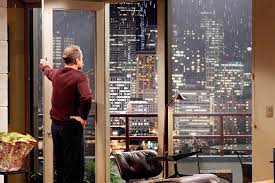

In [1]:
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use('bmh')

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x) 
pd.set_option("display.float_format", lambda x: "${:,.2f}".format(x))

In [2]:
#Extracting the data from data folder
df = pd.read_csv('data/eda_project_data.csv')
df.head(10)


,id,waterfront,view,condition,grade,yr_renovated,zipcode,price,date
0,7129300520,NaN,$0.00,3,7,$0.00,98178,"$221,900.00",2014-10-13
1,6414100192,$0.00,$0.00,3,7,"$19,910.00",98125,"$538,000.00",2014-12-09
2,5631500400,$0.00,$0.00,3,6,NaN,98028,"$180,000.00",2015-02-25
3,2487200875,$0.00,$0.00,5,7,$0.00,98136,"$604,000.00",2014-12-09
4,1954400510,$0.00,$0.00,3,8,$0.00,98074,"$510,000.00",2015-02-18
5,7237550310,$0.00,$0.00,3,11,$0.00,98053,"$1,230,000.00",2014-05-12
6,1321400060,$0.00,$0.00,3,7,$0.00,98003,"$257,500.00",2014-06-27
7,2008000270,$0.00,NaN,3,7,$0.00,98198,"$291,850.00",2015-01-15
8,2414600126,$0.00,$0.00,3,7,$0.00,98146,"$229,500.00",2015-04-15
9,3793500160,$0.00,$0.00,3,7,$0.00,98038,"$323,000.00",2015-03-12


In [3]:
import psycopg2

In [4]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

In [5]:
type(df['date'][0])

pandas.Timestamp

In [6]:
df = df.astype({ "yr_renovated": "Int64"})

df["zipcode"] = df["zipcode"].astype(str)

df["condition"] = df["condition"].astype("category")

df["grade"] = df["grade"].astype("category")

df["waterfront"] = df["waterfront"].astype("Int64")

df["view"] = df["view"].astype("Int64")

### Fixing data types

We adjusted several columns from their default numeric types because their values don't represent quantities to calculate with they represent categories, flags, or identifiers:

- **`zipcode`** → `str`: a zip code is an identifier, not a number to average or sum.
- **`condition`** and **`grade`** → `category`: both are ordinal rating scales (e.g. overall condition, King County's grading system), not continuous measurements.
- **`view`** → `category`: represents the quality of the view on a fixed scale, not a quantity.
- **`waterfront`** → `Int64`: 
- **`yr_renovated`** → kept as `Int64` (nullable integer): still numeric since it's a year, but uses the nullable type to preserve any missing values. Note that `0` in this column means "never renovated," not year zero — this should be accounted for separately (e.g. a `was_renovated` flag) before using `yr_renovated` in any statistics or plots.

In [7]:
df.dtypes

id                       int64
waterfront               Int64
view                     Int64
condition             category
grade                 category
yr_renovated             Int64
zipcode                    str
price                  float64
date            datetime64[us]
dtype: object

In [8]:
# import missingno
import missingno as msno

In [9]:
# display number of missing values per column
df.isna().sum()

id                 0
waterfront      2391
view              63
condition          0
grade              0
yr_renovated    3848
zipcode            0
price              0
date               0
dtype: int64

<Axes: >

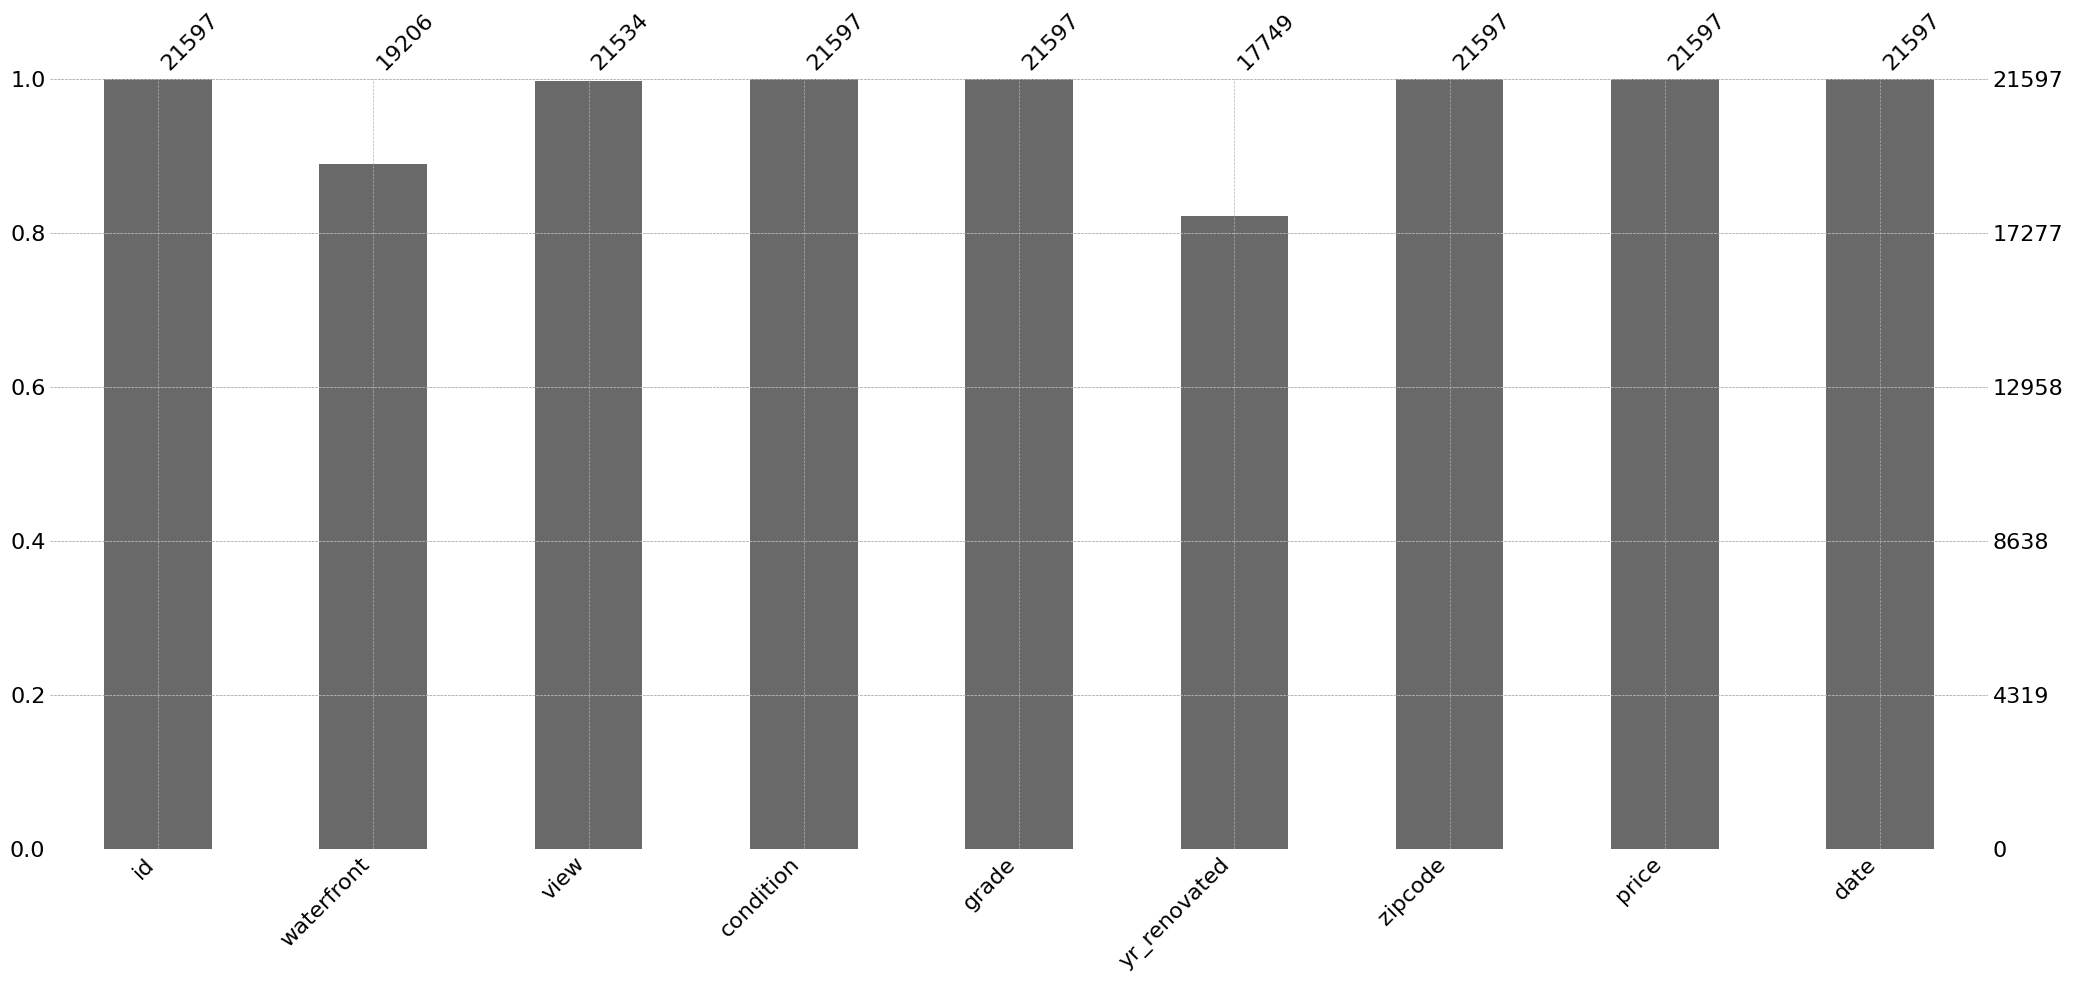

In [10]:
# plotting percentage of missing values per column
msno.bar(df)

We see that only two columns contain missing values: Less than 20 % of the data is missing in the column "yr_renovated" and 10 % of the data is missing in the column "waterfront"

DROPPING DATA

In [11]:
print(f"numbers of rows : {df.shape[0]}")
print(
    f"missing values in yr_renovated : {round(df.yr_renovated.isna().sum() / df.yr_renovated.shape[0] * 100, 2)} %"
)
print(
    f"missing values in waterfront : {round(df.waterfront.isna().sum() / df.waterfront.shape[0] * 100, 2)} %"
)
print(
    f"missing values in data frame : {round(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2)} %"
)

numbers of rows : 21597
missing values in yr_renovated : 17.82 %
missing values in waterfront : 11.07 %
missing values in data frame : 3.24 %


We have 21597 rows and about less than a quarter of them have missing values in at least one column.

In [12]:
# way 2: drop a row only if every value in it is missing

print(f"rows before dropna(how='all'): {df.shape[0]}")
df = df.dropna(how="all")

print(f"rows after dropna(how='all'): {df.shape[0]}")

rows before dropna(how='all'): 21597
rows after dropna(how='all'): 21597


In [13]:
df.head()

,id,waterfront,view,condition,grade,yr_renovated,zipcode,price,date
0,7129300520,<NA>,0,3,7,0,98178,"$221,900.00",2014-10-13
1,6414100192,0,0,3,7,19910,98125,"$538,000.00",2014-12-09
2,5631500400,0,0,3,6,<NA>,98028,"$180,000.00",2015-02-25
3,2487200875,0,0,5,7,0,98136,"$604,000.00",2014-12-09
4,1954400510,0,0,3,8,0,98074,"$510,000.00",2015-02-18


In [14]:
df['yr_renovated'].value_counts()

yr_renovated
0        17005
20140       73
20130       31
20030       31
20070       30
         ...  
19760        1
19460        1
19590        1
19340        1
19440        1
Name: count, Length: 70, dtype: Int64

In [15]:
df["yr_renovated"] = df["yr_renovated"].where(df["yr_renovated"] == 0, df["yr_renovated"] / 10)

In [16]:
cols = df.columns.tolist()
cols.insert(1, cols.pop(cols.index("date")))
df = df[cols]


We dont have any empty rows

In [17]:
df.head(20)

,id,date,waterfront,view,condition,grade,yr_renovated,zipcode,price
0,7129300520,2014-10-13,<NA>,0,3,7,0,98178,"$221,900.00"
1,6414100192,2014-12-09,0,0,3,7,1991,98125,"$538,000.00"
2,5631500400,2015-02-25,0,0,3,6,<NA>,98028,"$180,000.00"
3,2487200875,2014-12-09,0,0,5,7,0,98136,"$604,000.00"
4,1954400510,2015-02-18,0,0,3,8,0,98074,"$510,000.00"
5,7237550310,2014-05-12,0,0,3,11,0,98053,"$1,230,000.00"
6,1321400060,2014-06-27,0,0,3,7,0,98003,"$257,500.00"
7,2008000270,2015-01-15,0,<NA>,3,7,0,98198,"$291,850.00"
8,2414600126,2015-04-15,0,0,3,7,0,98146,"$229,500.00"
9,3793500160,2015-03-12,0,0,3,7,0,98038,"$323,000.00"


In [20]:
df.head()

,id,date,waterfront,view,condition,grade,yr_renovated,zipcode,price
0,7129300520,2014-10-13,<NA>,0,3,7,0,98178,"$221,900.00"
1,6414100192,2014-12-09,0,0,3,7,1991,98125,"$538,000.00"
2,5631500400,2015-02-25,0,0,3,6,<NA>,98028,"$180,000.00"
3,2487200875,2014-12-09,0,0,5,7,0,98136,"$604,000.00"
4,1954400510,2015-02-18,0,0,3,8,0,98074,"$510,000.00"


In [19]:
df["yr_renovated"].count()

np.int64(17749)